In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Preprocessing

In [2]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.8 MB/s eta 0:00:00


# CNN


In [3]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
import cv2
import ast
from torch.utils.data import Sampler
import random

Carica il dataset tramite il file csv.
Crea un dizionario con:
Paziente : { slope, intercept, slices, weeks, fvcs }.
Genera lo split dei pazienti in train/val/test, curante nel non dividere dati dei pazienti stessi.

In [4]:
class IPFDataLoader:
    """Carica e prepara i dati dal CSV e cartelle NPY"""

    def __init__(self, csv_path: str, npy_dir: str):
        """
        Args:
            csv_path: Path al CSV con [Patient, Weeks, FVC, fvc_poly3_coef, fvc_poly2_coef, fvc_poly1_coef, fvc_poly0_coef]
            npy_dir: Path alla cartella contenente le sottocartelle dei pazienti con file .npy
        """
        self.df = pd.read_csv(csv_path)
        self.npy_dir = npy_dir

        print(f"✅ Loaded {len(self.df)} records from CSV")
        print(f"✅ Unique patients in CSV: {self.df['Patient'].nunique()}")
        print(f"✅ NPY directory: {npy_dir}")
        print(f"📋 Columns: {self.df.columns.tolist()}")

        # Verifica che i pazienti nel CSV abbiano cartelle NPY
        self._verify_npy_availability()

    def _verify_npy_availability(self):
        """Verifica che ogni paziente nel CSV abbia una cartella con file .npy"""
        patients_csv = set(self.df['Patient'].unique())
        patients_npy = set([d for d in os.listdir(self.npy_dir)
                           if os.path.isdir(os.path.join(self.npy_dir, d))])

        missing = patients_csv - patients_npy
        extra = patients_npy - patients_csv

        if missing:
            print(f"⚠️  {len(missing)} pazienti nel CSV senza cartella NPY: {list(missing)[:5]}...")
        if extra:
            print(f"ℹ️  {len(extra)} cartelle NPY non nel CSV (verranno ignorate)")

        available = patients_csv & patients_npy
        print(f"✅ {len(available)} pazienti con dati completi (CSV + NPY)")

    def get_patient_data(self) -> Dict[str, Dict]:
        """
        Organizza i dati per paziente, caricando i path delle slice NPY

        Returns:
            {patient_id: {
                'poly3_coef': float,
                'poly2_coef': float,
                'poly1_coef': float,
                'poly0_coef': float,
                'slices': [list_of_npy_paths],
                'weeks': [list_of_weeks],
                'fvc_values': [list_of_fvc]
            }}
        """
        patient_data = {}

        for patient_id in self.df['Patient'].unique():
            patient_df = self.df[self.df['Patient'] == patient_id].sort_values('Weeks')

            # Coefficienti FVC (costanti per paziente)
            fvc_poly3_coef = patient_df['fvc_poly3_coef'].iloc[0]
            fvc_poly2_coef = patient_df['fvc_poly2_coef'].iloc[0]
            fvc_poly1_coef = patient_df['fvc_poly1_coef'].iloc[0]
            fvc_poly0_coef = patient_df['fvc_poly0_coef'].iloc[0]

            # Carica i path delle slice NPY dalla cartella del paziente
            patient_npy_folder = os.path.join(self.npy_dir, patient_id)

            if not os.path.exists(patient_npy_folder):
                print(f"⚠️  Cartella NPY non trovata per {patient_id}, paziente saltato")
                continue

            # Ottieni tutti i file .npy ordinati
            npy_files = sorted(glob.glob(os.path.join(patient_npy_folder, "*.npy")))

            if not npy_files:
                print(f"⚠️  Nessun file NPY trovato per {patient_id}, paziente saltato")
                continue

            # Timeline completa
            weeks = patient_df['Weeks'].tolist()
            fvc_values = patient_df['FVC'].tolist()

            patient_data[patient_id] = {
                'poly3_coef': float(fvc_poly3_coef),
                'poly2_coef': float(fvc_poly2_coef),
                'poly1_coef': float(fvc_poly1_coef),
                'poly0_coef': float(fvc_poly0_coef),
                'slices': npy_files,  # Lista completa di path assoluti ai .npy
                'n_slices': len(npy_files),
                'weeks': weeks,
                'fvc_values': fvc_values
            }

        print(f"\n📊 Patient data prepared for {len(patient_data)} patients")

        # Statistiche sulle slice
        slice_counts = [data['n_slices'] for data in patient_data.values()]
        print(f"   Min slices: {min(slice_counts)}")
        print(f"   Max slices: {max(slice_counts)}")
        print(f"   Avg slices: {np.mean(slice_counts):.2f}")

        return patient_data

    def compute_coef_scales(self, patient_list: List[str]) -> Dict[str, float]:
        """
        Calcola le scale (std) dei coefficienti per un subset di pazienti.
        Utile per normalizzazione nella loss function.

        Args:
            patient_list: Lista di patient IDs (es. train_patients)

        Returns:
            Dict con {'coef3': std, 'coef2': std, 'coef1': std, 'coef0': std}
        """
        # Filtra solo i pazienti nel subset
        subset_df = self.df[self.df['Patient'].isin(patient_list)]

        # Prendi un record per paziente (i coefficienti sono uguali per paziente)
        patient_coefs = subset_df.groupby('Patient').first()

        # Calcola std
        scale_coef3 = patient_coefs['fvc_poly3_coef'].std()
        scale_coef2 = patient_coefs['fvc_poly2_coef'].std()
        scale_coef1 = patient_coefs['fvc_poly1_coef'].std()
        scale_coef0 = patient_coefs['fvc_poly0_coef'].std()

        scales = {
            'coef3': scale_coef3,
            'coef2': scale_coef2,
            'coef1': scale_coef1,
            'coef0': scale_coef0
        }

        print(f"\n📊 Coefficient scales computed from {len(patient_list)} patients:")
        print(f"   coef3 std: {scale_coef3:.8f}")
        print(f"   coef2 std: {scale_coef2:.6f}")
        print(f"   coef1 std: {scale_coef1:.4f}")
        print(f"   coef0 std: {scale_coef0:.2f}")

        return scales

    def split_patients(self, test_size=0.2, val_size=0.1, random_state=42):
        """
        Split a livello di PAZIENTE per evitare data leakage

        Returns:
            train_patients, val_patients, test_patients (liste di patient IDs)
        """
        # Solo pazienti che hanno sia dati CSV che cartella NPY
        patient_npy_folders = set([d for d in os.listdir(self.npy_dir)
                                   if os.path.isdir(os.path.join(self.npy_dir, d))])
        csv_patients = set(self.df['Patient'].unique())

        valid_patients = np.array(list(csv_patients & patient_npy_folders))

        print(f"\n🔄 Splitting {len(valid_patients)} valid patients...")

        # Prima split: Train+Val vs Test
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_val_idx, test_idx = next(splitter.split(valid_patients, groups=valid_patients))

        train_val_patients = valid_patients[train_val_idx]
        test_patients = valid_patients[test_idx]

        # Seconda split: Train vs Val
        val_size_adjusted = val_size / (1 - test_size)
        splitter = GroupShuffleSplit(n_splits=1, test_size=val_size_adjusted, random_state=random_state)
        train_idx, val_idx = next(splitter.split(train_val_patients, groups=train_val_patients))

        train_patients = train_val_patients[train_idx]
        val_patients = train_val_patients[val_idx]

        print(f"✅ Data Split:")
        print(f"   Train: {len(train_patients)} patients")
        print(f"   Val: {len(val_patients)} patients")
        print(f"   Test: {len(test_patients)} patients")

        return train_patients.tolist(), val_patients.tolist(), test_patients.tolist()

    def __len__(self):
        return len(self.df)

In [5]:
class IPFSliceDataset(Dataset):
    """Dataset che carica singole slice NPY preprocessate con coefficienti come label"""

    def __init__(self, patient_list: List[str], patient_data: Dict,
                 transform=None, normalize_coefs=False):
        """
        Args:
            patient_list: Lista di patient IDs da includere (based on split)
            patient_data: Dict da IPFDataLoader.get_patient_data()
            transform: Trasformazioni aggiuntive (opzionali, le NPY sono già preprocessate)
            normalize_coefs: Se normalizzare i coefficienti (richiede scales)
        """
        self.data = []
        self.coef3s = []
        self.coef2s = []
        self.coef1s = []
        self.coef0s = []
        self.transform = transform
        self._cache = {}

        print("\n🔄 Initializing IPFSliceDataset...")

        # Crea lista (patient_id, slice_path, coefficients)
        for patient_id in patient_list:
            if patient_id not in patient_data:
                continue

            pdata = patient_data[patient_id]

            # Coefficienti
            coef3 = pdata['poly3_coef']
            coef2 = pdata['poly2_coef']
            coef1 = pdata['poly1_coef']
            coef0 = pdata['poly0_coef']

            # Slice NPY
            slices = pdata['slices']
            weeks = pdata['weeks']

            # Aggiungi ogni slice al dataset
            for slice_path in slices:
                self.data.append({
                    'patient_id': patient_id,
                    'slice_path': slice_path,
                    'poly3_coef': float(coef3),
                    'poly2_coef': float(coef2),
                    'poly1_coef': float(coef1),
                    'poly0_coef': float(coef0),
                    'weeks': weeks,
                })

                self.coef3s.append(float(coef3))
                self.coef2s.append(float(coef2))
                self.coef1s.append(float(coef1))
                self.coef0s.append(float(coef0))

        # Mappa: paziente -> indici delle sue slices nel dataset
        self.patient_to_indices = defaultdict(list)
        for idx, item in enumerate(self.data):
            self.patient_to_indices[item['patient_id']].append(idx)

        self.patients = list(self.patient_to_indices.keys())

        print(f"✅ Dataset created with {len(self.data)} slices from {len(patient_list)} patients")
        print(f"   Avg slices per patient: {len(self.data) / len(patient_list):.2f}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """
        Carica una slice NPY preprocessata.

        Returns:
            dict con:
                - 'image': Tensor [3, 224, 224] già preprocessato
                - 'coef3', 'coef2', 'coef1', 'coef0': coefficienti polinomiali
                - 'weeks': lista di settimane
                - 'patient_id': ID paziente
                - 'slice_path': path al file NPY
        """
        # Check cache first
        if idx in self._cache:
            return self._cache[idx]

        item = self.data[idx]

        try:
            # Carica NPY (già preprocessata: [224, 224] float32 normalizzata [0,1])
            img = np.load(item['slice_path'])

            # Verifica dimensioni
            if img.shape != (224, 224):
                raise ValueError(f"Unexpected shape: {img.shape}, expected (224, 224)")

            # Converti a 3 canali (RGB) se necessario
            # Se le tue NPY sono già [3, 224, 224], togli questa parte
            if img.ndim == 2:
                img = np.stack([img, img, img], axis=0)  # [3, 224, 224]

            # Applica trasformazioni aggiuntive se presenti
            if self.transform:
                img = self.transform(img)

            # Converti a tensor
            img_tensor = torch.FloatTensor(img)

        except Exception as e:
            print(f"⚠️  Error loading {item['slice_path']}: {e}")
            self._cache[idx] = None
            return None

        result = {
            'image': img_tensor,
            'coef3': torch.tensor(item['poly3_coef'], dtype=torch.float32),
            'coef2': torch.tensor(item['poly2_coef'], dtype=torch.float32),
            'coef1': torch.tensor(item['poly1_coef'], dtype=torch.float32),
            'coef0': torch.tensor(item['poly0_coef'], dtype=torch.float32),
            'weeks': item['weeks'],
            'patient_id': item['patient_id'],
            'slice_path': item['slice_path']
        }

        self._cache[idx] = result
        return result


# ============================================================
# UTILITY: COLLATE FUNCTION PER FILTRARE SLICE INVALIDE
# ============================================================

def collate_fn_filter_none(batch):
    """
    Collate function che filtra sample None (slice invalide).
    Utile se alcuni file NPY sono corrotti.
    """
    batch = [item for item in batch if item is not None]

    if len(batch) == 0:
        return None

    return torch.utils.data.dataloader.default_collate(batch)



In [6]:
class PatientBatchSampler(Sampler):
  def __init__(self,dataset,patients_per_batch=4,shuffle=True):
    self.ds = dataset
    self.shuffle = shuffle
    self.ppb =patients_per_batch

  def __iter__(self):
    patients = list(self.ds.patients)
    if self.shuffle:
      random.shuffle(patients)

    for i in range(0,len(patients),self.ppb):
      batch_pids = patients[i:i+self.ppb]
      idxs = []
      for pid in batch_pids:
        pidxs = list(self.ds.patient_to_indices[pid])
        idxs.extend(pidxs)
      yield idxs

  def __len__(self):
    from math import ceil
    return (len(self.ds.patients)+self.ppb -1) // self.ppb


def patient_group_collate(batch):
    # filtra None
    batch = [b for b in batch if b is not None]
    if not batch:
        return {
            'images': torch.empty(0, 3, 224, 224),
            'coef3s': torch.empty(0),
            'coef2s': torch.empty(0),
            'coef1s': torch.empty(0),
            'coef0s': torch.empty(0),
            'weeks': [],
            'patient_ids': [],
            'lengths': torch.empty(0, dtype=torch.long),
            'slice_paths': []
        }

    # ATTENZIONE: il sampler concatena per-paziente,
    # quindi gli elementi dello stesso paziente sono contigui nel "batch" qui.
    images = torch.stack([b['image'] for b in batch])            # (sumS, C, H, W)
    coef3s = torch.stack([b['coef3'] for b in batch]).view(-1)   # (sumS,)
    coef2s = torch.stack([b['coef2'] for b in batch]).view(-1)   # (sumS,)
    coef1s = torch.stack([b['coef1'] for b in batch]).view(-1)   # (sumS,)
    coef0s = torch.stack([b['coef0'] for b in batch]).view(-1)   # (sumS,)
    slice_paths = [b['slice_path'] for b in batch]
    weeks_s = [b['weeks'] for b in batch]



    lengths, pid_order = [], []
    i = 0
    while i < len(batch):
        pid = batch[i]['patient_id']
        j = i
        while j < len(batch) and batch[j]['patient_id'] == pid:
            j += 1
        lengths.append(j - i)
        pid_order.append(pid)
        i = j

    return {
        'images': images,
        'coef3s': coef3s,          # per-slice (ma target per paziente è lo stesso)
        'coef2s': coef2s,
        'coef1s': coef1s,
        'coef0s': coef0s,
        'weeks': weeks_s,  #Check this
        'patient_ids': pid_order,  # ordine dei pazienti nel batch
        'lengths': torch.tensor(lengths, dtype=torch.long),
        'slice_paths': slice_paths
    }

In [7]:
class RobustScaleNormalizedCoefLoss(nn.Module):
    def __init__(self, epsilon=1e-3):
        super().__init__()
        self.mse = nn.MSELoss()
        self.epsilon = epsilon
        self.global_scales = None

    def set_global_scales(self, scale_coef3, scale_coef2, scale_coef1, scale_coef0):
        """Imposta scale globali dal training set"""
        self.global_scales = {
            'coef3': max(scale_coef3, self.epsilon),
            'coef2': max(scale_coef2, self.epsilon),
            'coef1': max(scale_coef1, self.epsilon),
            'coef0': max(scale_coef0, self.epsilon)
        }
        print(f"✓ Global scales set: {self.global_scales}")

    def forward(self, pred_coef3, pred_coef2, pred_coef1, pred_coef0,
                target_coef3, target_coef2, target_coef1, target_coef0):

        # Usa scale globali (fisse, calcolate dal training set)
        if self.global_scales is None:
            raise ValueError("Global scales not set! Call set_global_scales() first.")

        weight_c0=1.4991956251954324
        weight_c1=2.083141259730476
        weight_c2=1.3507180090364124
        weight_c3=0.9441174665154592

        scale_coef3 = self.global_scales['coef3']
        scale_coef2 = self.global_scales['coef2']
        scale_coef1 = self.global_scales['coef1']
        scale_coef0 = self.global_scales['coef0']

        # Normalizza e calcola loss
        # CORREZIONE CHIAVE: Normalizzi SOLO il target. La predizione del modello (pred_coefX)
        # è ora il valore normalizzato che il modello deve imparare a predire.
        loss_coef3 = self.mse(pred_coef3, target_coef3 / scale_coef3)
        loss_coef2 = self.mse(pred_coef2, target_coef2 / scale_coef2)
        loss_coef1 = self.mse(pred_coef1, target_coef1 / scale_coef1)
        loss_coef0 = self.mse(pred_coef0, target_coef0 / scale_coef0)

        total_loss = (weight_c3*loss_coef3 + weight_c2*loss_coef2 + weight_c1*loss_coef1 + weight_c0*loss_coef0) / 4

        # Sanity check (il resto del codice rimane invariato)
        if torch.isnan(total_loss) or torch.isinf(total_loss):
            # ...
            return torch.tensor(float('inf'), device=pred_coef3.device)

        return total_loss

In [8]:
import timm
import torch.nn as nn

class SliceLevelCNN(nn.Module):
    def __init__(self, backbone_name='efficientnet_b0', pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained,
                                          in_chans=3, num_classes=0)  # 3 canali
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.LayerNorm(128),  # Changed from BatchNorm1d
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),   # Changed from BatchNorm1d
            nn.Dropout(dropout),
            nn.Linear(64, 4),
        )

    def forward(self, x):
        f = self.backbone(x)
        y = self.head(f).squeeze(-1)   # (N,)
        return y



In [10]:
checkpoint_dir = '/content/drive/MyDrive/Training FVC Polynomial/checkpoints_training_polynomial_npy'

In [9]:
class SlopeTrainer:
    def __init__(self, model, coef_scales, device='cuda' if torch.cuda.is_available() else 'cpu'):
        """
        Args:
            model: Il modello da trainare
            coef_scales: Dict con {'coef3': std, 'coef2': std, 'coef1': std, 'coef0': std}
            device: 'cuda' o 'cpu'
        """
        self.model = model.to(device)
        self.device = device
        self.criterion = RobustScaleNormalizedCoefLoss(epsilon=1e-3)

        # Imposta le scale subito
        self.criterion.set_global_scales(
            coef_scales['coef3'],
            coef_scales['coef2'],
            coef_scales['coef1'],
            coef_scales['coef0']
        )
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=0.0006212283360604225,
            weight_decay=2.6359580437822694e-06
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.42581883524759084,
            patience=10
        )
        self.train_losses = []
        self.val_losses = []

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        num_batches = 0

        for batch in tqdm(train_loader, desc='Training'):
            images = batch['images'].to(self.device)
            lengths = batch['lengths'].tolist()
            coef3s = batch['coef3s'].to(self.device)
            coef2s = batch['coef2s'].to(self.device)
            coef1s = batch['coef1s'].to(self.device)
            coef0s = batch['coef0s'].to(self.device)

            # Model outputs 4 values per slice: [coef3, coef2, coef1, coef0]
            preds_per_slice = self.model(images)  # Shape: [batch_size, 4]

            # Split predictions per coefficient
            pred_coef3 = preds_per_slice[:, 0]
            pred_coef2 = preds_per_slice[:, 1]
            pred_coef1 = preds_per_slice[:, 2]
            pred_coef0 = preds_per_slice[:, 3]

            # Aggregate per-patient (mean across slices)
            pred3_blocks = torch.split(pred_coef3, lengths)
            pred2_blocks = torch.split(pred_coef2, lengths)
            pred1_blocks = torch.split(pred_coef1, lengths)
            pred0_blocks = torch.split(pred_coef0, lengths)

            #Coefficients are taken drom the excel file, so they are not normalized in the beginning
            coef3s_blocks = torch.split(coef3s, lengths)
            coef2s_blocks = torch.split(coef2s, lengths)
            coef1s_blocks = torch.split(coef1s, lengths)
            coef0s_blocks = torch.split(coef0s, lengths)

            patient_pred_coef3 = torch.stack([blk.mean() for blk in pred3_blocks])
            patient_pred_coef2 = torch.stack([blk.mean() for blk in pred2_blocks])
            patient_pred_coef1 = torch.stack([blk.mean() for blk in pred1_blocks])
            patient_pred_coef0 = torch.stack([blk.mean() for blk in pred0_blocks])

            patient_coef3s = torch.stack([blk[0] for blk in coef3s_blocks])
            patient_coef2s = torch.stack([blk[0] for blk in coef2s_blocks])
            patient_coef1s = torch.stack([blk[0] for blk in coef1s_blocks])
            patient_coef0s = torch.stack([blk[0] for blk in coef0s_blocks])

            # Compute reconstruction loss
            self.optimizer.zero_grad()
            loss = self.criterion(
                patient_pred_coef3, patient_pred_coef2, patient_pred_coef1, patient_pred_coef0,
                patient_coef3s, patient_coef2s, patient_coef1s, patient_coef0s
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        return total_loss / num_batches

    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        num_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['images'].to(self.device)
                lengths = batch['lengths'].tolist()
                coef3s = batch['coef3s'].to(self.device)
                coef2s = batch['coef2s'].to(self.device)
                coef1s = batch['coef1s'].to(self.device)
                coef0s = batch['coef0s'].to(self.device)

                preds_per_slice = self.model(images)

                pred_coef3 = preds_per_slice[:, 0]
                pred_coef2 = preds_per_slice[:, 1]
                pred_coef1 = preds_per_slice[:, 2]
                pred_coef0 = preds_per_slice[:, 3]

                pred3_blocks = torch.split(pred_coef3, lengths)
                pred2_blocks = torch.split(pred_coef2, lengths)
                pred1_blocks = torch.split(pred_coef1, lengths)
                pred0_blocks = torch.split(pred_coef0, lengths)

                coef3s_blocks = torch.split(coef3s, lengths)
                coef2s_blocks = torch.split(coef2s, lengths)
                coef1s_blocks = torch.split(coef1s, lengths)
                coef0s_blocks = torch.split(coef0s, lengths)

                patient_pred_coef3 = torch.stack([blk.mean() for blk in pred3_blocks])
                patient_pred_coef2 = torch.stack([blk.mean() for blk in pred2_blocks])
                patient_pred_coef1 = torch.stack([blk.mean() for blk in pred1_blocks])
                patient_pred_coef0 = torch.stack([blk.mean() for blk in pred0_blocks])

                patient_coef3s = torch.stack([blk[0] for blk in coef3s_blocks])
                patient_coef2s = torch.stack([blk[0] for blk in coef2s_blocks])
                patient_coef1s = torch.stack([blk[0] for blk in coef1s_blocks])
                patient_coef0s = torch.stack([blk[0] for blk in coef0s_blocks])

                loss = self.criterion(
                    patient_pred_coef3, patient_pred_coef2, patient_pred_coef1, patient_pred_coef0,
                    patient_coef3s, patient_coef2s, patient_coef1s, patient_coef0s
                )


                total_loss += loss.item()
                num_batches += 1

        return total_loss / num_batches

In [11]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm


class ProgressionPredictor:
    def __init__(self, model, dataset, patient_data, patient_data_fvc, scales, device='cuda'):
        """
        Args:
            model: Trained model
            dataset: IPFSliceDataset (con file NPY)
            patient_data: Dict from IPFDataLoader.get_patient_data()
            patient_data_fvc: Dict con {patient_id: {'weeks': [...], 'fvc': [...]}}
            scales: Dict con coefficient scales (per denormalizzazione se necessaria)
            device: 'cuda' o 'cpu'
        """
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.dataset = dataset
        self.patient_data = patient_data
        self.patient_data_fvc = patient_data_fvc
        self.scales = scales

    def predict_patient_coefficients(self, patient_id: str, verbose: bool = False) -> np.ndarray:
        """
        Predicts polynomial coefficients by aggregating all slices for a patient.

        Args:
            patient_id: Patient ID
            verbose: If True, print debug info

        Returns:
            1D array [c0, c1, c2, c3]
        """
        if verbose:
            print(f"\n{'='*70}")
            print(f"Predicting coefficients for patient: {patient_id}")
            print(f"{'='*70}")

        # Check if patient has slices in dataset
        if patient_id not in self.dataset.patient_to_indices:
            if verbose:
                print(f"⚠️  No slices found for patient {patient_id}")
            return np.zeros(4, dtype=np.float32)

        patient_indices = self.dataset.patient_to_indices[patient_id]

        if verbose:
            print(f"✓ Found {len(patient_indices)} slices for patient")

        all_coefficients = []

        with torch.no_grad():
            for idx in patient_indices:
                try:
                    sample = self.dataset[idx]

                    if sample is None:
                        if verbose:
                            print(f"  ⚠️  Slice {idx} is None, skipping")
                        continue

                    image = sample['image'].unsqueeze(0).to(self.device)

                    # Model output
                    outputs = self.model(image)

                    # Handle different output formats
                    if isinstance(outputs, dict):
                        coef3_pred = outputs['coef3'].cpu().numpy()[0]
                        coef2_pred = outputs['coef2'].cpu().numpy()[0]
                        coef1_pred = outputs['coef1'].cpu().numpy()[0]
                        coef0_pred = outputs['coef0'].cpu().numpy()[0]
                    elif isinstance(outputs, (tuple, list)):
                        if len(outputs) == 4:
                            coef3_pred = outputs[0].cpu().numpy()[0]
                            coef2_pred = outputs[1].cpu().numpy()[0]
                            coef1_pred = outputs[2].cpu().numpy()[0]
                            coef0_pred = outputs[3].cpu().numpy()[0]
                        else:
                            # Single output [batch_size, 4]
                            out = outputs[0].cpu().numpy()[0]
                            coef3_pred, coef2_pred, coef1_pred, coef0_pred = out
                    else:
                        # Single tensor [batch_size, 4]
                        out = outputs.cpu().numpy()[0]
                        coef3_pred, coef2_pred, coef1_pred, coef0_pred = out

                    # Store coefficients in [c0, c1, c2, c3] order
                    # IMPORTANTE: Il modello predice valori NORMALIZZATI
                    # Dobbiamo denormalizzare moltiplicando per le scale
                    coeffs_pred = np.array([
                        coef0_pred * self.scales['coef0'],
                        coef1_pred * self.scales['coef1'],
                        coef2_pred * self.scales['coef2'],
                        coef3_pred * self.scales['coef3']
                    ])
                    all_coefficients.append(coeffs_pred)

                except Exception as e:
                    if verbose:
                        print(f"  ❌ Error predicting slice {idx}: {e}")
                    continue

        if not all_coefficients:
            if verbose:
                print(f"⚠️  No valid predictions for patient {patient_id}")
            return np.zeros(4, dtype=np.float32)

        # Average predictions across all slices
        all_coefficients = np.stack(all_coefficients, axis=0)
        mean_coeffs = all_coefficients.mean(axis=0)

        # Debug comparison
        if verbose and patient_id in self.patient_data:
            true_coeffs = np.array([
                self.patient_data[patient_id]['poly0_coef'],
                self.patient_data[patient_id]['poly1_coef'],
                self.patient_data[patient_id]['poly2_coef'],
                self.patient_data[patient_id]['poly3_coef']
            ])

            print(f"\n📊 Coefficient Comparison:")
            print(f"  {'Coef':<6} {'Predicted':<15} {'True':<15} {'Error':<15} {'Rel Error %':<15}")
            print(f"  {'-'*70}")
            for i, name in enumerate(['c0', 'c1', 'c2', 'c3']):
                pred_val = mean_coeffs[i]
                true_val = true_coeffs[i]
                error = abs(pred_val - true_val)
                rel_error = (error / abs(true_val) * 100) if true_val != 0 else float('inf')
                print(f"  {name:<6} {pred_val:<15.6f} {true_val:<15.6f} {error:<15.6f} {rel_error:<15.2f}")

            print(f"\n📈 Prediction Statistics:")
            print(f"  Number of slices: {len(all_coefficients)}")
            print(f"  Std across slices:")
            for i, name in enumerate(['c0', 'c1', 'c2', 'c3']):
                print(f"    {name}: {all_coefficients[:, i].std():.6f}")

        return mean_coeffs

    def predict_fvc_at_week(self, coefficients: np.ndarray, week: float) -> float:
        """
        Calculate predicted FVC for a specific week using polynomial coefficients.

        Args:
            coefficients: Array of 4 polynomial coefficients [c0, c1, c2, c3]
            week: Week number for prediction

        Returns:
            Predicted FVC value: c0 + c1*week + c2*week^2 + c3*week^3
        """
        fvc_predicted = (coefficients[0] +
                        coefficients[1] * week +
                        coefficients[2] * (week ** 2) +
                        coefficients[3] * (week ** 3))
        return float(fvc_predicted)

    def evaluate_fvc(self, patient_id: str, verbose: bool = False) -> float:
        """
        Evaluate FVC prediction error for a patient.

        Args:
            patient_id: Patient ID
            verbose: If True, print detailed info

        Returns:
            Mean absolute error across all weeks
        """
        # Get predicted polynomial coefficients
        predicted_coeffs = self.predict_patient_coefficients(patient_id, verbose=verbose)

        # Check if patient has FVC data
        if patient_id not in self.patient_data_fvc:
            if verbose:
                print(f"⚠️  No FVC data found for patient {patient_id}")
            return float('nan')

        # Actual FVC data for the patient
        actual_fvc = self.patient_data_fvc[patient_id]['fvc']
        patient_weeks = self.patient_data_fvc[patient_id]['weeks']

        fvc_errors = []
        predictions = []

        for week, actual_fvc_value in zip(patient_weeks, actual_fvc):
            fvc_predicted = self.predict_fvc_at_week(predicted_coeffs, week)
            fvc_error = abs(fvc_predicted - actual_fvc_value)
            fvc_errors.append(fvc_error)
            predictions.append(fvc_predicted)

        mean_fvc_error = np.mean(fvc_errors)

        if verbose:
            print(f"\n📊 FVC Prediction Results:")
            print(f"  {'Week':<8} {'True FVC':<12} {'Pred FVC':<12} {'Error':<12}")
            print(f"  {'-'*50}")
            for w, true_val, pred_val, err in zip(patient_weeks, actual_fvc, predictions, fvc_errors):
                print(f"  {w:<8} {true_val:<12.2f} {pred_val:<12.2f} {err:<12.2f}")
            print(f"  {'-'*50}")
            print(f"  Mean Error: {mean_fvc_error:.2f}")

        return mean_fvc_error

    def evaluate_test_set(self, patient_list, verbose_per_patient: bool = False):
        """
        Evaluate mean FVC error across all test patients.

        Args:
            patient_list: List of patient IDs
            verbose_per_patient: If True, print details for each patient

        Returns:
            Mean FVC error across all patients
        """
        fvc_errors_final = []
        valid_patients = 0
        skipped_patients = 0

        print(f"\n{'='*70}")
        print(f"EVALUATING TEST SET ({len(patient_list)} patients)")
        print(f"{'='*70}\n")

        for patient_id in tqdm(patient_list, desc='Evaluating patients'):
            if patient_id not in self.patient_data:
                skipped_patients += 1
                if verbose_per_patient:
                    print(f"⚠️  Skipping {patient_id}: not in patient_data")
                continue

            if patient_id not in self.patient_data_fvc:
                skipped_patients += 1
                if verbose_per_patient:
                    print(f"⚠️  Skipping {patient_id}: no FVC data")
                continue

            error = self.evaluate_fvc(patient_id, verbose=verbose_per_patient)

            if not np.isnan(error):
                fvc_errors_final.append(error)
                valid_patients += 1

        mean_fvc_error_final = np.mean(fvc_errors_final) if fvc_errors_final else float('nan')

        print(f"\n{'='*70}")
        print(f"TEST SET RESULTS")
        print(f"{'='*70}")
        print(f"Total patients: {len(patient_list)}")
        print(f"Valid evaluations: {valid_patients}")
        print(f"Skipped: {skipped_patients}")
        print(f"Mean FVC error: {mean_fvc_error_final:.2f} mL")
        print(f"Std FVC error: {np.std(fvc_errors_final):.2f} mL")
        print(f"Min FVC error: {np.min(fvc_errors_final):.2f} mL")
        print(f"Max FVC error: {np.max(fvc_errors_final):.2f} mL")
        print(f"{'='*70}\n")

        return mean_fvc_error_final

    def evaluate_fvc_detailed(self, patient_id: str) -> pd.DataFrame:
        """
        Get detailed per-week predictions and errors for a patient.

        Returns:
            DataFrame with columns: week, fvc_true, fvc_pred, error
        """
        predicted_coeffs = self.predict_patient_coefficients(patient_id, verbose=False)

        if patient_id not in self.patient_data_fvc:
            return pd.DataFrame()

        actual_fvc = self.patient_data_fvc[patient_id]['fvc']
        patient_weeks = self.patient_data_fvc[patient_id]['weeks']

        results = []
        for week, actual_fvc_value in zip(patient_weeks, actual_fvc):
            fvc_predicted = self.predict_fvc_at_week(predicted_coeffs, week)
            fvc_error = abs(fvc_predicted - actual_fvc_value)
            results.append({
                'week': week,
                'fvc_true': actual_fvc_value,
                'fvc_pred': fvc_predicted,
                'error': fvc_error
            })

        return pd.DataFrame(results)

    def get_patient_coefficients(self, patient_id: str) -> dict:
        """Get the predicted polynomial coefficients for a patient"""
        coeffs = self.predict_patient_coefficients(patient_id, verbose=False)
        return {
            'c0': float(coeffs[0]),
            'c1': float(coeffs[1]),
            'c2': float(coeffs[2]),
            'c3': float(coeffs[3])
        }


    def evaluate_per_coefficient(self, patient_list):
        """Evaluate MAE per each coefficient"""
        errors = {'c0': [], 'c1': [], 'c2': [], 'c3': []}

        for patient_id in tqdm(patient_list):
            if patient_id not in self.patient_data:
                continue

            pred = self.predict_patient_coefficients(patient_id, verbose=False)
            true = np.array([
                self.patient_data[patient_id]['poly0_coef'],
                self.patient_data[patient_id]['poly1_coef'],
                self.patient_data[patient_id]['poly2_coef'],
                self.patient_data[patient_id]['poly3_coef']
            ])

            for i, key in enumerate(['c0', 'c1', 'c2', 'c3']):
                errors[key].append(abs(pred[i] - true[i]))

        print("\n📊 Per-Coefficient MAE:")
        for key, vals in errors.items():
            print(f"  {key}: {np.mean(vals):.6f} ± {np.std(vals):.6f}")


# Fold

In [ ]:
import os
import json
import copy
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import glob

# =============================================================================
# CONFIGURAZIONE
# =============================================================================
CSV_PATH = '/content/drive/MyDrive/Training FVC Polynomial/train_with_poly3_coefs.csv'
NPY_DIR = '/content/drive/MyDrive/npy_files/extracted_npy'  # <<<< NUOVO
TARGET_WEEK = 52
PROGRESSION_THRESHOLD = 0.10
EPOCHS_PER_FOLD = 30
IMAGE_SIZE = (224, 224)
N_FOLDS = 5
K = 4  # patients per batch
CHECKPOINT_DIR = '/content/drive/MyDrive/Training FVC Polynomial/checkpoints_kfold_poly_npy'

print("="*70)
print("IPF SLOPE PREDICTION - K-FOLD CROSS-VALIDATION (NPY)")
print("="*70)

# File JSON per progressione fold e risultati
progress_file = os.path.join(CHECKPOINT_DIR, 'cv_progress.json')
results_file = os.path.join(CHECKPOINT_DIR, 'cv_results.json')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# =============================================================================
# CARICAMENTO PROGRESSO DA JSON (se esiste)
# =============================================================================
completed_folds = set()
fold_results = []

# Progressione fold (quali sono già completate)
if os.path.exists(progress_file):
    try:
        with open(progress_file, 'r') as f:
            data = json.load(f)
        completed_folds = set(data.get('completed_folds', []))
        print(f"\n✓ Trovato file di progresso. Fold già completate: {sorted(completed_folds)}")
    except Exception as e:
        print(f"\n⚠️ Errore nel leggere {progress_file}: {e}")
        print("Procedo come se nessuna fold fosse completata.")

# Risultati fold precedenti
if os.path.exists(results_file):
    try:
        with open(results_file, 'r') as f:
            fold_results = json.load(f)
        print(f"✓ Trovato file di risultati con {len(fold_results)} fold salvate.")
    except Exception as e:
        print(f"\n⚠️ Errore nel leggere {results_file}: {e}")
        print("Procedo con lista risultati vuota.")

# =============================================================================
# STEP 1: Load data
# =============================================================================

print("\n[1/5] Loading data from CSV and NPY directory...")
data_loader = IPFDataLoader(csv_path=CSV_PATH, npy_dir=NPY_DIR)  # <<<< AGGIORNATO
patient_data = data_loader.get_patient_data()

# Ottieni solo pazienti con dati completi (CSV + NPY folder)
all_patients = list(patient_data.keys())
print(f"✓ Total patients with complete data: {len(all_patients)}")

# Statistiche sulle slice
n_slices_list = [data['n_slices'] for data in patient_data.values()]
print(f"  Slices per patient - Min: {min(n_slices_list)}, Max: {max(n_slices_list)}, Avg: {np.mean(n_slices_list):.2f}")

# =============================================================================
# STEP 2: Split test set (20% held out)
# =============================================================================
print("\n[2/5] Splitting data...")
train_patients, test_patients = stratified_split_by_fvc(patient_data)
test_size = int(0.2 * len(all_patients))
np.random.seed(42)
np.random.shuffle(all_patients)

test_patients = all_patients[:test_size]
cv_patients = all_patients[test_size:]

print(f"✓ CV patients: {len(cv_patients)} (for {N_FOLDS}-fold CV)")
print(f"✓ Test patients: {len(test_patients)} (held out)")

# =============================================================================
# STEP 3: K-Fold Cross-Validation
# =============================================================================

print(f"\n[3/5] Running {N_FOLDS}-fold cross-validation...")


kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(cv_patients)):
    fold_number = fold_idx + 1

    # Skip if fold already completed (da JSON)
    if fold_number in completed_folds:
        print(f"\n⏭️  Skipping Fold {fold_number}/{N_FOLDS} (already completed)")
        continue

    print(f"\n{'='*70}")
    print(f"FOLD {fold_number}/{N_FOLDS}")
    print(f"{'='*70}")

    # Get patient lists
    fold_train_patients = [cv_patients[i] for i in train_idx]
    fold_val_patients = [cv_patients[i] for i in val_idx]

    # Compute coefficient scales for normalization
    coef_scales = data_loader.compute_coef_scales(fold_train_patients)

    print(f"✓ Train: {len(fold_train_patients)} patients")
    print(f"✓ Val:   {len(fold_val_patients)} patients")

    # Create datasets (usando IPFSliceDataset aggiornato per NPY)
    fold_train_dataset = IPFSliceDataset(
        fold_train_patients,
        patient_data,
        transform=None,  # Niente transform, NPY già preprocessati
        normalize_coefs=False  # <<<< AGGIORNATO (era normalize_slope)
    )

    fold_val_dataset = IPFSliceDataset(
        fold_val_patients,
        patient_data,
        transform=None,
        normalize_coefs=False
    )

    print(f"  Train dataset: {len(fold_train_dataset)} slices")
    print(f"  Val dataset: {len(fold_val_dataset)} slices")

    # Create data loaders
    fold_train_loader = DataLoader(
        fold_train_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            fold_train_dataset,
            patients_per_batch=K,
            shuffle=True  # Shuffle for training
        ),
        collate_fn=patient_group_collate,
    )

    fold_val_loader = DataLoader(
        fold_val_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            fold_val_dataset,
            patients_per_batch=K,
            shuffle=False  # NO shuffle for validation
        ),
        collate_fn=patient_group_collate,
    )

    # Initialize model and trainer
    model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True)
    trainer = SlopeTrainer(model, coef_scales)

    # Create checkpoint directory for this fold
    fold_checkpoint_dir = f'{CHECKPOINT_DIR}/fold_{fold_number}'
    os.makedirs(fold_checkpoint_dir, exist_ok=True)

    # Check for existing checkpoint
    fold_checkpoint_path = f'{fold_checkpoint_dir}/last_checkpoint.pth'
    start_epoch = 0
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    max_patience = 10

    if os.path.exists(fold_checkpoint_path):
        print(f"\n✓ Found checkpoint for fold {fold_number}, loading...")
        checkpoint = torch.load(
            fold_checkpoint_path,
            map_location='cuda' if torch.cuda.is_available() else 'cpu'
        )
        model.load_state_dict(checkpoint['model_state_dict'])
        trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        trainer.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint['patience_counter']

        # Load best model state if it exists
        best_model_path = f'{fold_checkpoint_dir}/best_model.pth'
        if os.path.exists(best_model_path):
            best_model_state = torch.load(
                best_model_path,
                map_location='cuda' if torch.cuda.is_available() else 'cpu'
            )['model_state_dict']

        print(f"  ✓ Resumed from epoch {start_epoch}, best val loss: {best_val_loss:.6f}")
    else:
        print(f"\n🆕 Starting fresh training for fold {fold_number}")

    # Training loop with early stopping
    print(f"\n🏋️  Training fold {fold_number}...")
    for epoch in range(start_epoch, EPOCHS_PER_FOLD):
        train_loss = trainer.train_epoch(fold_train_loader)
        val_loss = trainer.validate(fold_val_loader)

        # Log progress
        if epoch % 5 == 0 or epoch == EPOCHS_PER_FOLD - 1:
            print(f"  Epoch {epoch+1}/{EPOCHS_PER_FOLD} - "
                  f"Train: {train_loss:.6f}, Val: {val_loss:.6f}, "
                  f"Patience: {patience_counter}/{max_patience}")

        trainer.scheduler.step(val_loss)

        # Update best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            # Save best model
            torch.save({
                'model_state_dict': best_model_state,
                'val_loss': best_val_loss,
                'train_loss': train_loss,
                'epoch': epoch
            }, f'{fold_checkpoint_dir}/best_model.pth')
            print(f"  ✨ New best model saved (val_loss: {best_val_loss:.6f})")
        else:
            patience_counter += 1

        # Save checkpoint every epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'scheduler_state_dict': trainer.scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'train_loss': train_loss,
            'val_loss': val_loss
        }, fold_checkpoint_path)

        # Early stopping
        if patience_counter >= max_patience:
            print(f"  🛑 Early stopping at epoch {epoch+1}")
            break

    # Se per qualche motivo best_model_state è ancora None, uso lo stato corrente
    if best_model_state is None:
        print("  ⚠️ best_model_state è None, uso lo stato corrente del modello.")
        best_model_state = copy.deepcopy(model.state_dict())

    # Load best model and evaluate
    model.load_state_dict(best_model_state)

    print(f"\n✅ Fold {fold_number} Completed:")
    print(f"  Best Val Loss: {best_val_loss:.6f}")

    # Aggiorna struttura risultati in memoria
    fold_results.append({
        'fold': fold_number,
        'val_loss': float(best_val_loss),
        'n_train': len(fold_train_patients),
        'n_val': len(fold_val_patients),
        'n_train_slices': len(fold_train_dataset),
        'n_val_slices': len(fold_val_dataset)
    })

    # Mark fold as completed and save progress su JSON
    completed_folds.add(fold_number)

    # Salva progressione fold
    with open(progress_file, 'w') as f:
        json.dump({'completed_folds': sorted(list(completed_folds))}, f)

    # Salva risultati fold
    with open(results_file, 'w') as f:
        json.dump(fold_results, f, indent=2)

    print(f"✅ Fold {fold_number} saved. Progress: {len(completed_folds)}/{N_FOLDS} folds")

# =============================================================================
# STEP 4: Print Cross-Validation Summary
# =============================================================================

if len(completed_folds) == N_FOLDS:
    print(f"\n{'='*70}")
    print("CROSS-VALIDATION SUMMARY")
    print(f"{'='*70}")

    val_losses = [r['val_loss'] for r in fold_results]

    print(f"\nValidation Loss across folds:")
    for r in fold_results:
        print(f"  Fold {r['fold']}: {r['val_loss']:.6f}")

    print(f"\nMean Val Loss: {np.mean(val_losses):.6f} ± {np.std(val_losses):.6f}")
    print(f"Best Fold: {min(fold_results, key=lambda x: x['val_loss'])['fold']} "
          f"(Val Loss: {min(val_losses):.6f})")

    print("\n✅ All folds completed successfully!")
else:
    print(f"\n⚠️  Cross-validation incomplete: {len(completed_folds)}/{N_FOLDS} folds done")
    print(f"   Remaining folds: {sorted(set(range(1, N_FOLDS+1)) - completed_folds)}")

IPF SLOPE PREDICTION - K-FOLD CROSS-VALIDATION (NPY)

[1/5] Loading data from CSV and NPY directory...
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/npy_files/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_poly3_coef', 'fvc_poly2_coef', 'fvc_poly1_coef', 'fvc_poly0_coef']
✅ 176 pazienti con dati completi (CSV + NPY)

📊 Patient data prepared for 176 patients
   Min slices: 4
   Max slices: 11
   Avg slices: 10.20
✓ Total patients with complete data: 176
  Slices per patient - Min: 4, Max: 11, Avg: 10.20

[2/5] Splitting data...
✓ CV patients: 141 (for 5-fold CV)
✓ Test patients: 35 (held out)

[3/5] Running 5-fold cross-validation...

FOLD 1/5

📊 Coefficient scales computed from 112 patients:
   coef3 std: 0.02448797
   coef2 std: 2.868462
   coef1 std: 152.1838
   coef0 std: 3027.41
✓ Train: 112 patients
✓ Val:   29 patients

🔄 Initializing IPFSliceDataset...
✅ Dat

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

✓ Global scales set: {'coef3': 0.024487967829251098, 'coef2': 2.868461734660589, 'coef1': 152.1837886374672, 'coef0': 3027.409457528648}

🆕 Starting fresh training for fold 1

🏋️  Training fold 1...


Training: 100%|██████████| 28/28 [00:08<00:00,  3.17it/s]


...

  Epoch 1/30 - Train: 1.127528, Val: 1.010348, Patience: 0/10
  ✨ New best model saved (val_loss: 1.010348)


Training: 100%|██████████| 29/29 [00:06<00:00,  4.34it/s]


  Epoch 6/30 - Train: 0.968131, Val: 1.062704, Patience: 4/10


Training: 100%|██████████| 29/29 [00:07<00:00,  3.92it/s]


  Epoch 11/30 - Train: 0.870756, Val: 1.272581, Patience: 9/10
  🛑 Early stopping at epoch 11

✅ Fold 5 Completed:
  Best Val Loss: 1.010348
✅ Fold 5 saved. Progress: 5/5 folds

CROSS-VALIDATION SUMMARY

Validation Loss across folds:
  Fold 1: 0.499055
  Fold 2: 0.489527
  Fold 3: 0.192014
  Fold 4: 5.212007
  Fold 5: 1.010348

Mean Val Loss: 1.480590 ± 1.884179
Best Fold: 3 (Val Loss: 0.192014)

✅ All folds completed successfully!


# Final

In [12]:
def stratified_split_by_fvc(patient_data, test_size=0.2, random_state=42):
    """Split stratificato basato su FVC baseline"""
    patients = list(patient_data.keys())

    # Estrai poly0_coef
    fvc_baseline = np.array([patient_data[p]['poly0_coef'] for p in patients])

    # Crea quartili per stratificazione
    bins = np.percentile(fvc_baseline, [0, 25, 50, 75, 100])
    strata = np.digitize(fvc_baseline, bins[1:-1])

    print(f"\n📊 Stratification bins (poly0_coef):")
    for i in range(len(bins)-1):
        count = np.sum(strata == i)
        print(f"  Bin {i}: [{bins[i]:.0f}, {bins[i+1]:.0f}] - {count} patients")

    # Stratified split
    from sklearn.model_selection import StratifiedShuffleSplit

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(patients, strata))

    train_patients = [patients[i] for i in train_idx]
    test_patients = [patients[i] for i in test_idx]

    # Verifica bilanciamento
    train_fvc = [patient_data[p]['poly0_coef'] for p in train_patients]
    test_fvc = [patient_data[p]['poly0_coef'] for p in test_patients]

    print(f"\n✓ Train poly0_coef: {np.mean(train_fvc):.2f} ± {np.std(train_fvc):.2f}")
    print(f"✓ Test poly0_coef:  {np.mean(test_fvc):.2f} ± {np.std(test_fvc):.2f}")

    return train_patients, test_patients

In [13]:
import os
import json
import copy
import numpy as np
import torch
import glob
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, r2_score

# =============================================================================
# CONFIGURAZIONE
# =============================================================================
CSV_PATH = '/content/drive/MyDrive/Training FVC Polynomial/train_with_poly3_coefs.csv'
NPY_DIR = '/content/drive/MyDrive/npy_files/extracted_npy'
CHECKPOINT_DIR = '/content/drive/MyDrive/Training FVC Polynomial/final_model_after_hyperparameter_tuning'
EPOCHS = 100  # Più epoche perché hai più dati
K = 2  # patients per batch
EARLY_STOPPING_PATIENCE = 25

print("="*70)
print("IPF SLOPE PREDICTION - FINAL TRAINING ON ALL DATA")
print("="*70)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# =============================================================================
# STEP 1: Load data
# =============================================================================

print("\n[1/4] Loading data from CSV and NPY directory...")
data_loader = IPFDataLoader(csv_path=CSV_PATH, npy_dir=NPY_DIR)
patient_data = data_loader.get_patient_data()

all_patients = list(patient_data.keys())
print(f"✓ Total patients with complete data: {len(all_patients)}")

# Statistiche
n_slices_list = [data['n_slices'] for data in patient_data.values()]
print(f"  Slices per patient - Min: {min(n_slices_list)}, Max: {max(n_slices_list)}, Avg: {np.mean(n_slices_list):.2f}")

# =============================================================================
# STEP 2: Train/Test Split (80/20)
# =============================================================================

print("\n[2/4] Splitting into Train (80%) and Test (20%)...")
train_patients,test_patients = stratified_split_by_fvc(patient_data)

print(f"✓ Train patients: {len(train_patients)} ({len(train_patients)/len(all_patients)*100:.1f}%)")
print(f"✓ Test patients: {len(test_patients)} ({len(test_patients)/len(all_patients)*100:.1f}%)")

# Compute coefficient scales (per normalizzazione loss)
coef_scales = data_loader.compute_coef_scales(train_patients)

# =============================================================================
# STEP 3: Create Datasets and DataLoaders
# =============================================================================

print("\n[3/4] Creating datasets and dataloaders...")

train_dataset = IPFSliceDataset(
    train_patients,
    patient_data,
    transform=None,
    normalize_coefs=False
)

test_dataset = IPFSliceDataset(
    test_patients,
    patient_data,
    transform=None,
    normalize_coefs=False
)

print(f"✓ Train dataset: {len(train_dataset)} slices from {len(train_patients)} patients")
print(f"✓ Test dataset: {len(test_dataset)} slices from {len(test_patients)} patients")

train_loader = DataLoader(
    train_dataset,
    num_workers=4,
    pin_memory=True,
    batch_sampler=PatientBatchSampler(
        train_dataset,
        patients_per_batch=K,
        shuffle=True
    ),
    collate_fn=patient_group_collate,
)

test_loader = DataLoader(
    test_dataset,
    num_workers=4,
    pin_memory=True,
    batch_sampler=PatientBatchSampler(
        test_dataset,
        patients_per_batch=K,
        shuffle=False
    ),
    collate_fn=patient_group_collate,
)

print(f"✓ Train loader: {len(train_loader)} batches")
print(f"✓ Test loader: {len(test_loader)} batches")

# =============================================================================
# STEP 4: Initialize Model and Trainer
# =============================================================================

print("\n[4/4] Initializing model and starting training...")

model = SliceLevelCNN(backbone_name='efficientnet_b0', pretrained=True,dropout=0.1922202140729591)
trainer = SlopeTrainer(model, coef_scales)

# Training state
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'checkpoint.pth')
best_model_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
start_epoch = 0
best_test_loss = float('inf')
best_model_state = None
patience_counter = 0

# Resume from checkpoint if exists
if os.path.exists(checkpoint_path):
    print(f"\n✓ Found existing checkpoint, resuming...")
    checkpoint = torch.load(
        checkpoint_path,
        map_location='cuda' if torch.cuda.is_available() else 'cpu'
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    trainer.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_test_loss = checkpoint['best_test_loss']
    patience_counter = checkpoint['patience_counter']

    if os.path.exists(best_model_path):
        best_model_state = torch.load(
            best_model_path,
            map_location='cuda' if torch.cuda.is_available() else 'cpu'
        )['model_state_dict']

    print(f"  Resumed from epoch {start_epoch}")
    print(f"  Best test loss so far: {best_test_loss:.6f}")
else:
    print(f"\n🆕 Starting fresh training")

# =============================================================================
# TRAINING LOOP
# =============================================================================

print(f"\n🏋️  Training for up to {EPOCHS} epochs...")
print(f"   Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"{'='*70}\n")

training_history = {
    'train_loss': [],
    'test_loss': [],
    'epochs': []
}

for epoch in range(start_epoch, EPOCHS):
    # Train
    train_loss = trainer.train_epoch(train_loader)

    # Evaluate on test set
    test_loss = trainer.validate(test_loader)

    # Log
    training_history['train_loss'].append(train_loss)
    training_history['test_loss'].append(test_loss)
    training_history['epochs'].append(epoch)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Train: {train_loss:.6f} | "
          f"Test: {test_loss:.6f} | "
          f"Patience: {patience_counter:2d}/{EARLY_STOPPING_PATIENCE}")

    # Learning rate scheduling
    trainer.scheduler.step(test_loss)

    # Update best model
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0

        # Save best model
        torch.save({
            'model_state_dict': best_model_state,
            'test_loss': best_test_loss,
            'train_loss': train_loss,
            'epoch': epoch,
            'coef_scales': coef_scales,
            'n_train_patients': len(train_patients),
            'n_test_patients': len(test_patients)
        }, best_model_path)

        print(f"  ✨ New best model saved (test_loss: {best_test_loss:.6f})")
    else:
        patience_counter += 1

    # Save checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': trainer.optimizer.state_dict(),
        'scheduler_state_dict': trainer.scheduler.state_dict(),
        'best_test_loss': best_test_loss,
        'patience_counter': patience_counter,
        'train_loss': train_loss,
        'test_loss': test_loss,
        'training_history': training_history
    }, checkpoint_path)

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        break

# =============================================================================
# FINAL EVALUATION
# =============================================================================

print(f"\n{'='*70}")
print("FINAL EVALUATION ON TEST SET")
print(f"{'='*70}")

# Load best model
if best_model_state is None:
    print("⚠️  No best model found, using current state")
    best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

# Final test loss
final_test_loss = trainer.validate(test_loader)

print(f"\n✅ Training completed!")
print(f"   Best test loss: {best_test_loss:.6f}")
print(f"   Total epochs: {epoch+1}")
print(f"   Model saved to: {best_model_path}")

# Save training history
history_path = os.path.join(CHECKPOINT_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(training_history, f, indent=2)

print(f"   Training history saved to: {history_path}")


IPF SLOPE PREDICTION - FINAL TRAINING ON ALL DATA

[1/4] Loading data from CSV and NPY directory...
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/npy_files/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_poly3_coef', 'fvc_poly2_coef', 'fvc_poly1_coef', 'fvc_poly0_coef']
✅ 176 pazienti con dati completi (CSV + NPY)

📊 Patient data prepared for 176 patients
   Min slices: 4
   Max slices: 11
   Avg slices: 10.20
✓ Total patients with complete data: 176
  Slices per patient - Min: 4, Max: 11, Avg: 10.20

[2/4] Splitting into Train (80%) and Test (20%)...

📊 Stratification bins (poly0_coef):
  Bin 0: [-6469, 2052] - 44 patients
  Bin 1: [2052, 2823] - 44 patients
  Bin 2: [2823, 3369] - 44 patients
  Bin 3: [3369, 27444] - 44 patients

✓ Train poly0_coef: 2813.86 ± 2833.36
✓ Test poly0_coef:  2850.90 ± 1892.69
✓ Train patients: 140 (79.5%)
✓ Test patients: 36 (20.5%)

📊

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

✓ Global scales set: {'coef3': 0.02345732737003012, 'coef2': 2.7810625340296506, 'coef1': 145.25298992304107, 'coef0': 2843.5309155864834}

✓ Found existing checkpoint, resuming...
  Resumed from epoch 39
  Best test loss so far: 0.726834

🏋️  Training for up to 100 epochs...
   Early stopping patience: 25



Training: 100%|██████████| 70/70 [01:53<00:00,  1.62s/it]


...

Epoch  47/100 | Train: 1.021288 | Test: 1.080037 | Patience: 22/25


Training: 100%|██████████| 70/70 [00:09<00:00,  7.43it/s]


Epoch  48/100 | Train: 0.987047 | Test: 1.195595 | Patience: 23/25


Training: 100%|██████████| 70/70 [00:08<00:00,  7.87it/s]


Epoch  49/100 | Train: 0.997651 | Test: 0.973279 | Patience: 24/25

🛑 Early stopping triggered at epoch 49

FINAL EVALUATION ON TEST SET

✅ Training completed!
   Best test loss: 0.726834
   Total epochs: 49
   Model saved to: /content/drive/MyDrive/Training FVC Polynomial/final_model_after_hyperparameter_tuning/best_model.pth
   Training history saved to: /content/drive/MyDrive/Training FVC Polynomial/final_model_after_hyperparameter_tuning/training_history.json


In [14]:

# =============================================================================
# FINAL EVALUATION
# =============================================================================

print(f"\n{'='*70}")
print("FINAL EVALUATION ON TEST SET")
print(f"{'='*70}")

# Load best model
if best_model_state is None:
    print("⚠️  No best model found, using current state")
    best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

# Final test loss
final_test_loss = trainer.validate(test_loader)

print(f"\n✅ Training completed!")
print(f"   Best test loss: {best_test_loss:.6f}")
print(f"   Total epochs: {epoch+1}")
print(f"   Model saved to: {best_model_path}")

# Save training history
history_path = os.path.join(CHECKPOINT_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(training_history, f, indent=2)

print(f"   Training history saved to: {history_path}")

# =============================================================================
# DETAILED TEST SET ANALYSIS (OPTIONAL)
# =============================================================================

print(f"\n{'='*70}")
print("DETAILED TEST SET ANALYSIS")
print(f"{'='*70}")

# Collect predictions per patient
model.eval()
patient_predictions = {}

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue

        images = batch['images'].to(trainer.device)
        patient_ids = batch['patient_ids']

        # Get predictions (formato dipende dal tuo modello)
        outputs = model(images)

        # Gestisci diversi formati di output
        if isinstance(outputs, dict):
            # Se il modello ritorna un dict
            pred_coef3 = outputs['coef3']
            pred_coef2 = outputs['coef2']
            pred_coef1 = outputs['coef1']
            pred_coef0 = outputs['coef0']
        elif isinstance(outputs, (tuple, list)):
            # Se il modello ritorna una tupla/lista
            if len(outputs) == 4:
                pred_coef3, pred_coef2, pred_coef1, pred_coef0 = outputs
            elif len(outputs) == 1:
                # Output concatenato [batch_size, 4]
                predictions = outputs[0]
                pred_coef3 = predictions[:, 0]
                pred_coef2 = predictions[:, 1]
                pred_coef1 = predictions[:, 2]
                pred_coef0 = predictions[:, 3]
            else:
                raise ValueError(f"Unexpected output format: {len(outputs)} elements")
        else:
            # Output singolo [batch_size, 4]
            pred_coef3 = outputs[:, 0]
            pred_coef2 = outputs[:, 1]
            pred_coef1 = outputs[:, 2]
            pred_coef0 = outputs[:, 3]

        # Store per patient (average delle slice)
        for i, pid in enumerate(patient_ids):
            if pid not in patient_predictions:
                patient_predictions[pid] = {
                    'pred_coef3': [],
                    'pred_coef2': [],
                    'pred_coef1': [],
                    'pred_coef0': [],
                    'true_coef3': batch['coef3s'][i].item(),
                    'true_coef2': batch['coef2s'][i].item(),
                    'true_coef1': batch['coef1s'][i].item(),
                    'true_coef0': batch['coef0s'][i].item()
                }

            patient_predictions[pid]['pred_coef3'].append(pred_coef3[i].item())
            patient_predictions[pid]['pred_coef2'].append(pred_coef2[i].item())
            patient_predictions[pid]['pred_coef1'].append(pred_coef1[i].item())
            patient_predictions[pid]['pred_coef0'].append(pred_coef0[i].item())

# Compute per-patient metrics
true_coef1 = []
pred_coef1 = []

for pid, pdata in patient_predictions.items():
    true_coef1.append(pdata['true_coef1'])
    pred_coef1.append(np.mean(pdata['pred_coef1']))  # Average delle slice

# Metrics
mae = mean_absolute_error(true_coef1, pred_coef1)
r2 = r2_score(true_coef1, pred_coef1)

print(f"\nPer-Patient Metrics (coef1 - slope):")
print(f"  MAE: {mae:.6f}")
print(f"  R²:  {r2:.6f}")

print(f"\n✅ Final model ready for deployment!")
print(f"   Use: {best_model_path}")
print(f"{'='*70}\n")


FINAL EVALUATION ON TEST SET

✅ Training completed!
   Best test loss: 0.726834
   Total epochs: 49
   Model saved to: /content/drive/MyDrive/Training FVC Polynomial/final_model_after_hyperparameter_tuning/best_model.pth
   Training history saved to: /content/drive/MyDrive/Training FVC Polynomial/final_model_after_hyperparameter_tuning/training_history.json

DETAILED TEST SET ANALYSIS

Per-Patient Metrics (coef1 - slope):
  MAE: 64.373205
  R²:  -0.037197

✅ Final model ready for deployment!
   Use: /content/drive/MyDrive/Training FVC Polynomial/final_model_after_hyperparameter_tuning/best_model.pth



In [15]:
df_all_train = pd.read_csv('/content/drive/MyDrive/train.csv')

print(test_patients)

df_test = df_all_train[df_all_train["Patient"].isin(test_patients)]

# Verify the filtered data
print(f"Test set data preview:")
print(df_test.head())

# Group by PatientID to extract their weeks and FVC values
test_patient_data = {}

for pid, group in df_test.groupby("Patient"):
    group_sorted = group.sort_values("Weeks")  # Sort by week to ensure order

    # Extract weeks and FVC values as lists
    weeks = group_sorted["Weeks"].tolist()
    fvc = group_sorted["FVC"].tolist()

    # Store the data for each patient
    test_patient_data[pid] = {
        "weeks": weeks,
        "fvc": fvc
    }

print(f"Extracted data for {len(test_patient_data)} test patients.")


['ID00241637202264294508775', 'ID00060637202187965290703', 'ID00076637202199015035026', 'ID00020637202178344345685', 'ID00035637202182204917484', 'ID00234637202261078001846', 'ID00128637202219474716089', 'ID00011637202177653955184', 'ID00299637202280383305867', 'ID00190637202244450116191', 'ID00125637202218590429387', 'ID00094637202205333947361', 'ID00264637202270643353440', 'ID00009637202177434476278', 'ID00358637202295388077032', 'ID00216637202257988213445', 'ID00224637202259281193413', 'ID00075637202198610425520', 'ID00229637202260254240583', 'ID00197637202246865691526', 'ID00077637202199102000916', 'ID00228637202259965313869', 'ID00192637202245493238298', 'ID00422637202311677017371', 'ID00426637202313170790466', 'ID00132637202222178761324', 'ID00221637202258717315571', 'ID00398637202303897337979', 'ID00115637202211874187958', 'ID00110637202210673668310', 'ID00105637202208831864134', 'ID00202637202249376026949', 'ID00102637202206574119190', 'ID00032637202181710233084', 'ID0001263720

In [16]:
# Carica il modello migliore
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])

# Crea predictor (SENZA moltiplicare per scales)
test_predictor = ProgressionPredictor(
    model=model,
    dataset=test_dataset,
    patient_data=patient_data,
    patient_data_fvc=test_patient_data,
    scales=coef_scales,  # Passalo ma non viene usato per la denormalizzazione
    device='cuda'
)

# Valuta su test set
mean_fvc_error = test_predictor.evaluate_test_set(
    test_patients,
    verbose_per_patient=False  # Set True per vedere dettagli per ogni paziente
)

print(f"\n✅ Mean FVC prediction error: {mean_fvc_error:.2f} mL")

# Per vedere dettagli di un singolo paziente
patient_id = test_patients[0]
error = test_predictor.evaluate_fvc(patient_id, verbose=True)


EVALUATING TEST SET (36 patients)



Evaluating patients: 100%|██████████| 36/36 [00:04<00:00,  7.88it/s]



TEST SET RESULTS
Total patients: 36
Valid evaluations: 36
Skipped: 0
Mean FVC error: 682.73 mL
Std FVC error: 553.67 mL
Min FVC error: 63.53 mL
Max FVC error: 2329.00 mL


✅ Mean FVC prediction error: 682.73 mL

Predicting coefficients for patient: ID00241637202264294508775
✓ Found 11 slices for patient

📊 Coefficient Comparison:
  Coef   Predicted       True            Error           Rel Error %    
  ----------------------------------------------------------------------
  c0     1418.328125     1400.312528     18.015597       1.29           
  c1     -5.500658       -7.471489       1.970831        26.38          
  c2     0.156716        0.250975        0.094259        37.56          
  c3     -0.000919       -0.003311       0.002392        72.25          

📈 Prediction Statistics:
  Number of slices: 11
  Std across slices:
    c0: 567.065247
    c1: 5.398736
    c2: 0.163841
    c3: 0.001549

📊 FVC Prediction Results:
  Week     True FVC     Pred FVC     Error       
  ----------

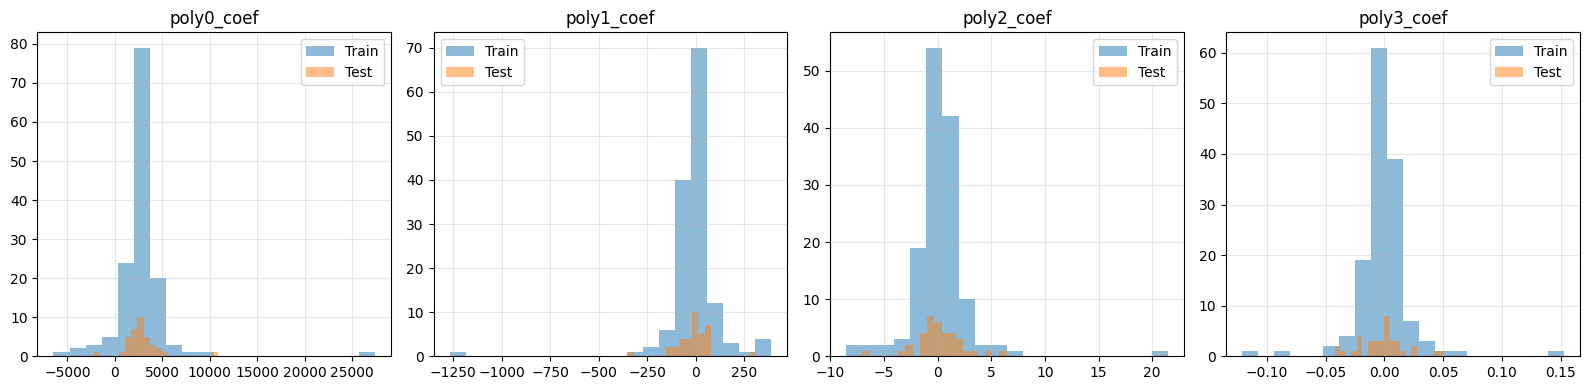

In [17]:
import matplotlib.pyplot as plt

# Confronta train vs test
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, coef_name in enumerate(['poly0_coef', 'poly1_coef', 'poly2_coef', 'poly3_coef']):
    train_vals = [patient_data[p][coef_name] for p in train_patients]
    test_vals = [patient_data[p][coef_name] for p in test_patients]

    axes[i].hist(train_vals, alpha=0.5, label='Train', bins=20)
    axes[i].hist(test_vals, alpha=0.5, label='Test', bins=20)
    axes[i].set_title(f'{coef_name}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

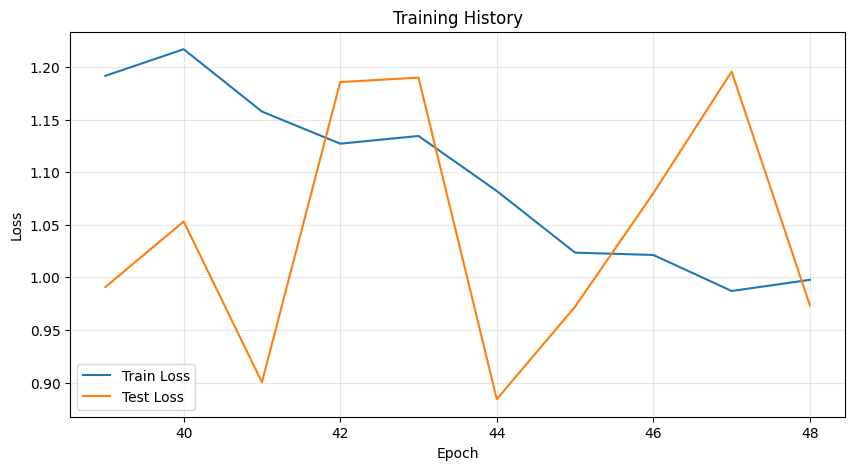

Final train loss: 0.997651
Final test loss: 0.973279


In [18]:
# Carica history
import json
history_path = os.path.join(CHECKPOINT_DIR, 'training_history.json')
with open(history_path, 'r') as f:
    history = json.load(f)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(history['epochs'], history['train_loss'], label='Train Loss')
plt.plot(history['epochs'], history['test_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Training History')
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.6f}")
print(f"Final test loss: {history['test_loss'][-1]:.6f}")

In [19]:
# Usa
test_predictor.evaluate_per_coefficient(test_patients)

100%|██████████| 36/36 [00:03<00:00, 11.86it/s]


📊 Per-Coefficient MAE:
  c0: 1166.764210 ± 1508.358284
  c1: 60.127396 ± 73.890487
  c2: 1.620662 ± 1.599292
  c3: 0.014310 ± 0.012985


# Hyperparameter Tuning


In [12]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 15.7 MB/s eta 0:00:00


In [13]:
# All'inizio del notebook/script, PRIMA di importare torch
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
torch.cuda.empty_cache()

# Poi il resto degli import...

In [14]:
import optuna
from optuna.trial import TrialState
import torch
from torch.utils.data import DataLoader
import numpy as np
import json
import os
import glob

# =============================================================================
# CONFIGURAZIONE
# =============================================================================
CSV_PATH = '/content/drive/MyDrive/Training FVC Polynomial/train_with_poly3_coefs.csv'
NPY_DIR = '/content/drive/MyDrive/npy_files/extracted_npy'
OPTUNA_STUDY_DIR = '/content/drive/MyDrive/Training FVC Polynomial/optuna_study'
N_TRIALS = 50  # Numero di combinazioni da provare
EPOCHS_PER_TRIAL = 15  # <<<< RIDOTTO da 20 a 15 per OOM
TIMEOUT_HOURS = 12  # Timeout totale

# Memory optimization settings
GRADIENT_ACCUMULATION_STEPS = 2  # <<<< NUOVO: accumula gradienti
MAX_BATCH_SIZE = 8  # <<<< NUOVO: limita batch size massimo

os.makedirs(OPTUNA_STUDY_DIR, exist_ok=True)

# =============================================================================
# OBJECTIVE FUNCTION
# =============================================================================

def objective(trial):
    """
    Objective function per Optuna.
    Ritorna: validation loss da minimizzare
    """

    # =============================================================================
    # 1. SUGGEST HYPERPARAMETERS
    # =============================================================================

    # Learning rate (log scale)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

    # Loss weights
    weight_c0 = trial.suggest_float('weight_c0', 0.1, 20.0)
    weight_c1 = trial.suggest_float('weight_c1', 0.1, 20.0)
    weight_c2 = trial.suggest_float('weight_c2', 0.1, 10.0)
    weight_c3 = trial.suggest_float('weight_c3', 0.1, 10.0)

    # Batch size (patients per batch) - LIMITATO per OOM
    batch_size = trial.suggest_categorical('batch_size', [2, 4, 6])  # <<<< MAX 6 invece di 16

    # Backbone - SOLO EfficientNet-B0 per memory
    backbone = trial.suggest_categorical('backbone', [
        'efficientnet_b0'  # <<<< SOLO B0 per evitare OOM
        # efficientnet_b1 e resnet50 richiedono troppa memoria
    ])

    # Dropout
    dropout = trial.suggest_float('dropout', 0.0, 0.5)

    # Weight decay
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # Scheduler parameters
    scheduler_factor = trial.suggest_float('scheduler_factor', 0.1, 0.5)
    scheduler_patience = trial.suggest_int('scheduler_patience', 3, 10)

    print(f"\n{'='*70}")
    print(f"Trial {trial.number}: Testing hyperparameters")
    print(f"{'='*70}")
    print(f"  LR: {lr:.6f}")
    print(f"  Weights: c0={weight_c0:.2f}, c1={weight_c1:.2f}, c2={weight_c2:.2f}, c3={weight_c3:.2f}")
    print(f"  Batch size: {batch_size}")
    print(f"  Backbone: {backbone}")
    print(f"  Dropout: {dropout:.2f}")
    print(f"  Weight decay: {weight_decay:.6f}")
    print(f"  Scheduler: factor={scheduler_factor:.2f}, patience={scheduler_patience}")

    # =============================================================================
    # 2. LOAD DATA (con stratified split)
    # =============================================================================

    data_loader = IPFDataLoader(csv_path=CSV_PATH, npy_dir=NPY_DIR)
    patient_data = data_loader.get_patient_data()

    # Stratified split
    all_patients = list(patient_data.keys())
    fvc_baseline = np.array([patient_data[p]['poly0_coef'] for p in all_patients])
    bins = np.percentile(fvc_baseline, [0, 25, 50, 75, 100])
    strata = np.digitize(fvc_baseline, bins[1:-1])

    from sklearn.model_selection import StratifiedShuffleSplit
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(splitter.split(all_patients, strata))

    train_patients = [all_patients[i] for i in train_idx]
    val_patients = [all_patients[i] for i in val_idx]

    # Coefficient scales
    coef_scales = data_loader.compute_coef_scales(train_patients)

    # Create datasets
    train_dataset = IPFSliceDataset(train_patients, patient_data)
    val_dataset = IPFSliceDataset(val_patients, patient_data)

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            train_dataset,
            patients_per_batch=batch_size,
            shuffle=True
        ),
        collate_fn=patient_group_collate,
    )

    val_loader = DataLoader(
        val_dataset,
        num_workers=4,
        pin_memory=True,
        batch_sampler=PatientBatchSampler(
            val_dataset,
            patients_per_batch=batch_size,
            shuffle=False
        ),
        collate_fn=patient_group_collate,
    )

    # =============================================================================
    # 3. CREATE MODEL
    # =============================================================================

    model = SliceLevelCNN(
        backbone_name=backbone,
        pretrained=True,
        dropout=dropout
    )

    # =============================================================================
    # 4. CREATE CUSTOM TRAINER WITH WEIGHTED LOSS
    # =============================================================================

    class WeightedSlopeTrainer:
        def __init__(self, model, coef_scales, weights, lr, weight_decay, scheduler_params):
            self.model = model
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self.model.to(self.device)

            self.coef_scales = coef_scales
            self.weights = weights

            self.optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer,
                mode='min',
                factor=scheduler_params['factor'],
                patience=scheduler_params['patience']
            )

            self.criterion = torch.nn.MSELoss()

        def train_epoch(self, dataloader):
            self.model.train()
            total_loss = 0
            n_batches = 0

            # <<<< GRADIENT ACCUMULATION per ridurre memoria
            accumulation_steps = GRADIENT_ACCUMULATION_STEPS
            self.optimizer.zero_grad()

            for batch_idx, batch in enumerate(dataloader):
                if batch is None:
                    continue

                images = batch['images'].to(self.device)
                true_c3 = batch['coef3s'].to(self.device)
                true_c2 = batch['coef2s'].to(self.device)
                true_c1 = batch['coef1s'].to(self.device)
                true_c0 = batch['coef0s'].to(self.device)

                # Forward
                outputs = self.model(images)

                # Parse outputs
                if isinstance(outputs, (tuple, list)):
                    pred_c3, pred_c2, pred_c1, pred_c0 = outputs
                else:
                    pred_c3 = outputs[:, 0]
                    pred_c2 = outputs[:, 1]
                    pred_c1 = outputs[:, 2]
                    pred_c0 = outputs[:, 3]

                # Normalize
                true_c3_norm = true_c3 / self.coef_scales['coef3']
                true_c2_norm = true_c2 / self.coef_scales['coef2']
                true_c1_norm = true_c1 / self.coef_scales['coef1']
                true_c0_norm = true_c0 / self.coef_scales['coef0']

                # Weighted loss
                loss = (
                    self.weights['c3'] * self.criterion(pred_c3, true_c3_norm) +
                    self.weights['c2'] * self.criterion(pred_c2, true_c2_norm) +
                    self.weights['c1'] * self.criterion(pred_c1, true_c1_norm) +
                    self.weights['c0'] * self.criterion(pred_c0, true_c0_norm)
                )

                # Scale loss by accumulation steps
                loss = loss / accumulation_steps

                # Backward
                loss.backward()

                # Update weights every accumulation_steps
                if (batch_idx + 1) % accumulation_steps == 0:
                    self.optimizer.step()
                    self.optimizer.zero_grad()

                total_loss += loss.item() * accumulation_steps
                n_batches += 1

                # <<<< CLEAR CACHE periodicamente
                if batch_idx % 10 == 0 and torch.cuda.is_available():
                    torch.cuda.empty_cache()

            return total_loss / n_batches if n_batches > 0 else 0

        def validate(self, dataloader):
            self.model.eval()
            total_loss = 0
            n_batches = 0

            with torch.no_grad():
                for batch in dataloader:
                    if batch is None:
                        continue

                    images = batch['images'].to(self.device)
                    true_c3 = batch['coef3s'].to(self.device)
                    true_c2 = batch['coef2s'].to(self.device)
                    true_c1 = batch['coef1s'].to(self.device)
                    true_c0 = batch['coef0s'].to(self.device)

                    outputs = self.model(images)

                    if isinstance(outputs, (tuple, list)):
                        pred_c3, pred_c2, pred_c1, pred_c0 = outputs
                    else:
                        pred_c3 = outputs[:, 0]
                        pred_c2 = outputs[:, 1]
                        pred_c1 = outputs[:, 2]
                        pred_c0 = outputs[:, 3]

                    true_c3_norm = true_c3 / self.coef_scales['coef3']
                    true_c2_norm = true_c2 / self.coef_scales['coef2']
                    true_c1_norm = true_c1 / self.coef_scales['coef1']
                    true_c0_norm = true_c0 / self.coef_scales['coef0']

                    loss = (
                        self.weights['c3'] * self.criterion(pred_c3, true_c3_norm) +
                        self.weights['c2'] * self.criterion(pred_c2, true_c2_norm) +
                        self.weights['c1'] * self.criterion(pred_c1, true_c1_norm) +
                        self.weights['c0'] * self.criterion(pred_c0, true_c0_norm)
                    )

                    total_loss += loss.item()
                    n_batches += 1

            return total_loss / n_batches if n_batches > 0 else 0

    # Initialize trainer
    weights = {
        'c0': weight_c0,
        'c1': weight_c1,
        'c2': weight_c2,
        'c3': weight_c3
    }

    scheduler_params = {
        'factor': scheduler_factor,
        'patience': scheduler_patience
    }

    trainer = WeightedSlopeTrainer(
        model, coef_scales, weights, lr, weight_decay, scheduler_params
    )

    # =============================================================================
    # 5. TRAINING LOOP
    # =============================================================================

    best_val_loss = float('inf')
    patience_counter = 0
    max_patience = 5  # Early stopping per trial

    for epoch in range(EPOCHS_PER_TRIAL):
        train_loss = trainer.train_epoch(train_loader)
        val_loss = trainer.validate(val_loader)

        trainer.scheduler.step(val_loss)

        # Report intermediate value per pruning
        trial.report(val_loss, epoch)

        # Handle pruning (interrompi trial non promettenti)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= max_patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    print(f"  Best val loss: {best_val_loss:.6f}")

    # =============================================================================
    # 6. CLEANUP MEMORY (CRITICO per evitare OOM tra trial)
    # =============================================================================

    # Delete model and trainer
    del model
    del trainer
    del train_loader
    del val_loader
    del train_dataset
    del val_dataset

    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    # Force garbage collection
    import gc
    gc.collect()

    return best_val_loss

# =============================================================================
# RUN OPTUNA STUDY
# =============================================================================

if __name__ == "__main__":
    # Create or load study
    study_name = "ipf_hyperparameter_tuning"
    storage_name = f"sqlite:///{OPTUNA_STUDY_DIR}/optuna_study.db"

    study = optuna.create_study(
        study_name=study_name,
        storage=storage_name,
        load_if_exists=True,
        direction='minimize',
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=5
        )
    )

    print(f"\n{'='*70}")
    print(f"STARTING OPTUNA HYPERPARAMETER TUNING")
    print(f"{'='*70}")
    print(f"Study name: {study_name}")
    print(f"Storage: {storage_name}")
    print(f"Max trials: {N_TRIALS}")
    print(f"Timeout: {TIMEOUT_HOURS} hours")
    print(f"{'='*70}\n")

    # Run optimization
    study.optimize(
        objective,
        n_trials=N_TRIALS,
        timeout=TIMEOUT_HOURS * 3600,
        show_progress_bar=True
    )

    # =============================================================================
    # RESULTS
    # =============================================================================

    print(f"\n{'='*70}")
    print("OPTIMIZATION COMPLETE")
    print(f"{'='*70}")

    print(f"\nNumber of finished trials: {len(study.trials)}")
    print(f"Number of pruned trials: {len([t for t in study.trials if t.state == TrialState.PRUNED])}")
    print(f"Number of complete trials: {len([t for t in study.trials if t.state == TrialState.COMPLETE])}")

    print(f"\n{'='*70}")
    print("BEST TRIAL")
    print(f"{'='*70}")

    best_trial = study.best_trial

    print(f"  Value (val loss): {best_trial.value:.6f}")
    print(f"\n  Best Hyperparameters:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # Save best params
    best_params_path = os.path.join(OPTUNA_STUDY_DIR, 'best_params.json')
    with open(best_params_path, 'w') as f:
        json.dump(best_trial.params, f, indent=2)

    print(f"\n✅ Best parameters saved to: {best_params_path}")

    # Visualization (if in notebook)
    try:
        from optuna.visualization import plot_optimization_history, plot_param_importances

        fig1 = plot_optimization_history(study)
        fig1.write_html(os.path.join(OPTUNA_STUDY_DIR, 'optimization_history.html'))

        fig2 = plot_param_importances(study)
        fig2.write_html(os.path.join(OPTUNA_STUDY_DIR, 'param_importances.html'))

        print(f"✅ Visualizations saved to: {OPTUNA_STUDY_DIR}")
    except:
        print("⚠️  Could not generate visualizations")

    print(f"\n{'='*70}\n")

[I 2025-12-01 10:50:56,488] Using an existing study with name 'ipf_hyperparameter_tuning' instead of creating a new one.



STARTING OPTUNA HYPERPARAMETER TUNING
Study name: ipf_hyperparameter_tuning
Storage: sqlite:////content/drive/MyDrive/Training FVC Polynomial/optuna_study/optuna_study.db
Max trials: 50
Timeout: 12 hours



  0%|          | 0/50 [00:00<?, ?it/s]


Trial 45: Testing hyperparameters
  LR: 0.000118
  Weights: c0=6.12, c1=2.27, c2=4.71, c3=2.52
  Batch size: 4
  Backbone: efficientnet_b0
  Dropout: 0.17
  Weight decay: 0.000008
  Scheduler: factor=0.38, patience=6
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/npy_files/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_poly3_coef', 'fvc_poly2_coef', 'fvc_poly1_coef', 'fvc_poly0_coef']
✅ 176 pazienti con dati completi (CSV + NPY)

📊 Patient data prepared for 176 patients
   Min slices: 4
   Max slices: 11
   Avg slices: 10.20

📊 Coefficient scales computed from 140 patients:
   coef3 std: 0.02345733
   coef2 std: 2.781063
   coef1 std: 145.2530
   coef0 std: 2843.53

🔄 Initializing IPFSliceDataset...
✅ Dataset created with 1424 slices from 140 patients
   Avg slices per patient: 10.17

🔄 Initializing IPFSliceDataset...
✅ Dataset created with 371 slices from 36 patie

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

  Early stopping at epoch 7
  Best val loss: 3.709996
[I 2025-12-01 12:14:30,909] Trial 92 finished with value: 3.709995594289568 and parameters: {'lr': 0.0003493739083247641, 'weight_c0': 1.3097802571830963, 'weight_c1': 2.6272353258917485, 'weight_c2': 1.8556337700973708, 'weight_c3': 0.6899107530416662, 'batch_size': 2, 'backbone': 'efficientnet_b0', 'dropout': 0.16053872650021314, 'weight_decay': 6.96669837741289e-06, 'scheduler_factor': 0.3533918548216175, 'scheduler_patience': 9}. Best is trial 87 with value: 3.1783746981786356.

Trial 93: Testing hyperparameters
  LR: 0.000333
  Weights: c0=1.43, c1=2.77, c2=1.92, c3=0.70
  Batch size: 2
  Backbone: efficientnet_b0
  Dropout: 0.17
  Weight decay: 0.000007
  Scheduler: factor=0.38, patience=9
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/npy_files/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_poly3_coef', 'f

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


  Early stopping at epoch 12
  Best val loss: 3.494589
[I 2025-12-01 12:16:42,554] Trial 93 finished with value: 3.494588760038217 and parameters: {'lr': 0.00033315370832803754, 'weight_c0': 1.4332375315315469, 'weight_c1': 2.7690965165980637, 'weight_c2': 1.9242961469734925, 'weight_c3': 0.6959162500454639, 'batch_size': 2, 'backbone': 'efficientnet_b0', 'dropout': 0.16879164202714417, 'weight_decay': 6.814281837930278e-06, 'scheduler_factor': 0.3786789138671519, 'scheduler_patience': 9}. Best is trial 87 with value: 3.1783746981786356.

Trial 94: Testing hyperparameters
  LR: 0.000432
  Weights: c0=1.14, c1=2.76, c2=2.19, c3=0.67
  Batch size: 2
  Backbone: efficientnet_b0
  Dropout: 0.16
  Weight decay: 0.000007
  Scheduler: factor=0.35, patience=9
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/npy_files/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_poly3_coef',

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


  Early stopping at epoch 11
  Best val loss: 3.956187
[I 2025-12-01 12:18:41,250] Trial 94 finished with value: 3.9561874113149114 and parameters: {'lr': 0.0004316440205393549, 'weight_c0': 1.1433791342413642, 'weight_c1': 2.7564298580937248, 'weight_c2': 2.1941213699668447, 'weight_c3': 0.6730414810178187, 'batch_size': 2, 'backbone': 'efficientnet_b0', 'dropout': 0.1605455982432748, 'weight_decay': 7.109868134603605e-06, 'scheduler_factor': 0.3518302675836393, 'scheduler_patience': 9}. Best is trial 87 with value: 3.1783746981786356.

OPTIMIZATION COMPLETE

Number of finished trials: 95
Number of pruned trials: 22
Number of complete trials: 71

BEST TRIAL
  Value (val loss): 3.178375

  Best Hyperparameters:
    lr: 0.0006212283360604225
    weight_c0: 1.4991956251954324
    weight_c1: 2.083141259730476
    weight_c2: 1.3507180090364124
    weight_c3: 0.9441174665154592
    batch_size: 2
    backbone: efficientnet_b0
    dropout: 0.1922202140729591
    weight_decay: 2.63595804378226